In [2]:
from pathlib import Path
import hashlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")

project_dir = Path.cwd()
if not (project_dir / "data" / "raw").is_dir():
    project_dir = project_dir.parent

data_dir = project_dir / "data" / "raw"
train_raw = pd.read_csv(data_dir / "train.csv", index_col="ID")
clients_raw = pd.read_csv(data_dir / "clientes.csv")


train = train_raw.copy()
clients = clients_raw.copy()

In [3]:
print(f"Train: {train.shape[0]:,} linhas e {train.shape[1]} colunas (sem o ID)")
print(f"Clientes: {clients.shape[0]:,} linhas e {clients.shape[1]} colunas")
print("Exemplos de compras:")
display(train.head())
print("Exemplos da tabela auxiliar:")
display(clients.head())

print("\nEstrutura do treino:")
train.info()
print("\nEstrutura dos clientes:")
clients.info()
display(train.dtypes.value_counts().rename("Número de colunas por tipo"))



Train: 6,534 linhas e 38 colunas (sem o ID)
Clientes: 1,143 linhas e 13 colunas
Exemplos de compras:


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,...,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,random_noise
ID,,,,,,,,,,,,,,,,,,,,,
10000000,558.11,510.90,453.75,104.36,0.0,0.0,57.15,153.099911,4.0,1.0,...,858.30,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,-0.660448
10000001,978.80,830.02,795.77,183.03,0.0,0.0,34.25,472.943134,32.0,1.0,...,2500.68,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,0.924510
10000002,10.33,12.00,8.40,1.93,0.0,0.0,3.60,6.097485,1.0,1.0,...,7899.80,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,-0.258730
10000003,856.83,696.61,696.61,160.22,0.0,0.0,0.00,408.167275,9.0,1.0,...,270.33,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,1.448402
10000004,1616.10,1488.85,1313.90,302.20,0.0,0.0,174.95,485.401864,33.0,1.0,...,2062.50,122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,-1.058890


Exemplos da tabela auxiliar:


,customer_id,country_or_region,commercial_region,island,municipality,city,postal_area,postal_code,street,address,customer_type,company_name,customer_since_year
0,842570,Country CT11: Land of The Final Version,Region RG37: We Will See Later,NaN,NaN,City CY417: Missing Cell Port,NaN,Postal code PC828: #REF! Delivery Route,NaN,Address AD1120: Cell Without a Home,NaN,Excel Is Not A Database Ltd 150,2018
1,770941,Country CT9: Land of The Final Version,NaN,NaN,NaN,NaN,NaN,Postal code PC56: #REF! Delivery Route,NaN,Address AD62: Cell Without a Home,NaN,Excel Is Not A Database Ltd 1064,2021
2,827053,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS2: The Pivot Archipelago,Municipality MU14: Council of Last Minute Edits,NaN,Postal area PA271: Hidden Sheet Sector,Postal code PC827: #REF! Delivery Route,Street ST170: PowerPoint New Walk,Address AD449: Cell Without a Home,NaN,Excel Is Not A Database Ltd 113,2016
3,494648,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS2: The Pivot Archipelago,Municipality MU14: Council of Last Minute Edits,NaN,Postal area PA271: Hidden Sheet Sector,Postal code PC826: #REF! Delivery Route,NaN,Address AD454: Cell Without a Home,NaN,Excel Is Not A Database Ltd 430,2015
4,429291,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS2: The Pivot Archipelago,Municipality MU14: Council of Last Minute Edits,NaN,Postal area PA271: Hidden Sheet Sector,Postal code PC826: #REF! Delivery Route,NaN,Address AD453: Cell Without a Home,NaN,Excel Is Not A Database Ltd 673,2015



Estrutura do treino:
<class 'pandas.DataFrame'>
Index: 6534 entries, 10000000 to 10007674
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Total a Pagar                   6469 non-null   float64
 1   Total Bruto                     6469 non-null   float64
 2   Total Liquido                   6469 non-null   float64
 3   Total Imp_                      6469 non-null   float64
 4   Total Portes                    6469 non-null   float64
 5   Total Desc_ Global              6469 non-null   float64
 6   Total Desc_ Linha               6469 non-null   float64
 7   Custo                           6469 non-null   float64
 8   N_ Detalhes                     6469 non-null   float64
 9   invoice_count_current_purchase  6469 non-null   float64
 10  repeat_purchase_90d             6534 non-null   int64  
 11  days_since_previous_purchase    5673 non-null   float64
 12  customer_tenure_d

float64    29
str         7
int64       2
Name: Número de colunas por tipo, dtype: int64

### Descrição dos datasets utilizados nesta etapa

Nesta etapa, a exploração utiliza apenas `train.csv` e a tabela auxiliar `clientes.csv`.

| Dataset | Linhas | Colunas no CSV | Conteúdo |
|---|---:|---:|---|
| `train.csv` | 6 534 | 39 | Compras com características e variável alvo, para exploração e desenvolvimento dos modelos. |
| `clientes.csv` | 1 143 | 13 | Informação adicional por cliente, associável através de `customer_id`. |

#### Variáveis de `train.csv`

As tabelas seguintes descrevem as 39 colunas do ficheiro de treino, incluindo a variável alvo `repeat_purchase_90d` e o identificador `ID`. Neste notebook, `ID` é utilizado como índice, pelo que o DataFrame apresenta 38 colunas.


##### Identificação e variável alvo

| Variável | Descrição |
|---|---|
| `ID` | Identificador da observação de compra; permite associar cada previsão à linha correspondente. No notebook, é usado como índice. |
| `customer_id` | Identificador do cliente e chave para associar a informação de clientes.csv. Pode repetir-se em compras diferentes. |
| `purchase_date` | Data associada à compra, armazenada como texto no CSV. |
| `repeat_purchase_90d` | Variável alvo: 1 indica recompra nos 90 dias seguintes e 0 indica ausência de recompra nesse período. Existe apenas em train.csv. |

##### Valores da compra atual

| Variável | Descrição |
|---|---|
| `Total a Pagar` | Montante total a pagar pela compra. |
| `Total Bruto` | Valor bruto da compra. |
| `Total Liquido` | Valor líquido da compra. |
| `Total Imp_` | Montante de impostos associado à compra. |
| `Total Portes` | Montante dos portes associado à compra. |
| `Total Desc_ Global` | Montante do desconto global da compra. |
| `Total Desc_ Linha` | Montante dos descontos aplicados às linhas da compra. |
| `Custo` | Custo registado para a compra; a definição contabilística deve ser confirmada. |

##### Dimensão e contexto da compra

| Variável | Descrição |
|---|---|
| `N_ Detalhes` | Número de detalhes ou linhas da compra; não equivale necessariamente à quantidade de unidades compradas. |
| `invoice_count_current_purchase` | Número de faturas associado à compra atual. |
| `payment_type` | Categoria do tipo de pagamento. |
| `salesperson` | Categoria que identifica o vendedor. |
| `commercial_zone` | Zona comercial associada à compra. |
| `transport_method` | Modalidade de transporte associada à compra. |
| `warehouse` | Armazém associado à compra. |
| `document_series` | Série do documento associado à compra. |

##### Histórico do cliente

| Variável | Descrição |
|---|---|
| `days_since_previous_purchase` | Número de dias desde a compra anterior. |
| `customer_tenure_days` | Antiguidade do cliente em dias no momento da compra; a data de referência inicial deve ser confirmada. |
| `prior_purchase_count` | Número de compras anteriores do cliente. |
| `prior_total_spend` | Montante total gasto anteriormente pelo cliente. |
| `prior_mean_purchase_value` | Valor médio das compras anteriores. |
| `prior_std_purchase_value` | Desvio-padrão dos valores das compras anteriores. |
| `prior_min_purchase_value` | Menor valor de compra no histórico anterior. |
| `prior_max_purchase_value` | Maior valor de compra no histórico anterior. |
| `prior_mean_gap_days` | Média dos intervalos, em dias, entre compras anteriores. |
| `prior_std_gap_days` | Desvio-padrão dos intervalos, em dias, entre compras anteriores. |

##### Atividade em janelas temporais

| Variável | Descrição |
|---|---|
| `purchase_count_30d` | Número de compras na janela histórica de 30 dias. |
| `spend_30d` | Montante gasto na janela histórica de 30 dias. |
| `purchase_count_90d` | Número de compras na janela histórica de 90 dias. |
| `spend_90d` | Montante gasto na janela histórica de 90 dias. |
| `purchase_count_180d` | Número de compras na janela histórica de 180 dias. |
| `spend_180d` | Montante gasto na janela histórica de 180 dias. |
| `purchase_count_365d` | Número de compras na janela histórica de 365 dias. |
| `spend_365d` | Montante gasto na janela histórica de 365 dias. |

##### Variável numérica adicional

| Variável | Descrição |
|---|---|
| `random_noise` | Variável numérica cujo nome sugere ruído. A sua utilidade deve ser avaliada nos dados, sem assumir que tem valor preditivo. |

#### Variáveis de `clientes.csv`

| Variável | Descrição |
|---|---|
| `customer_id` | Identificador do cliente, usado para associar esta tabela às compras. |
| `country_or_region` | País ou região do cliente. |
| `commercial_region` | Região comercial do cliente. |
| `island` | Ilha associada ao cliente; um valor em falta não permite, por si só, concluir que o campo não se aplica. |
| `municipality` | Município associado ao cliente. |
| `city` | Cidade associada ao cliente. |
| `postal_area` | Área postal associada ao cliente. |
| `postal_code` | Código postal; é uma categoria geográfica, não uma quantidade. |
| `street` | Rua associada ao cliente. |
| `address` | Morada do cliente. |
| `customer_type` | Campo destinado ao tipo de cliente. No ficheiro atual, todos os valores estão em falta. |
| `company_name` | Nome da empresa cliente. |
| `customer_since_year` | Ano de início da relação com o cliente, segundo o nome do campo. |

,Resultado
IDs de compra repetidos,0
Clientes distintos no treino,610
IDs repetidos na tabela de clientes,0
"Linhas integralmente repetidas, incluindo ID",0
Repetições adicionais sem ID e random_noise,10
Repetições adicionais do par cliente/data,12


,Compras por cliente
count,610.000000
mean,10.711475
std,19.969320
min,1.000000
25%,1.000000
50%,4.000000
75%,12.000000
max,277.000000


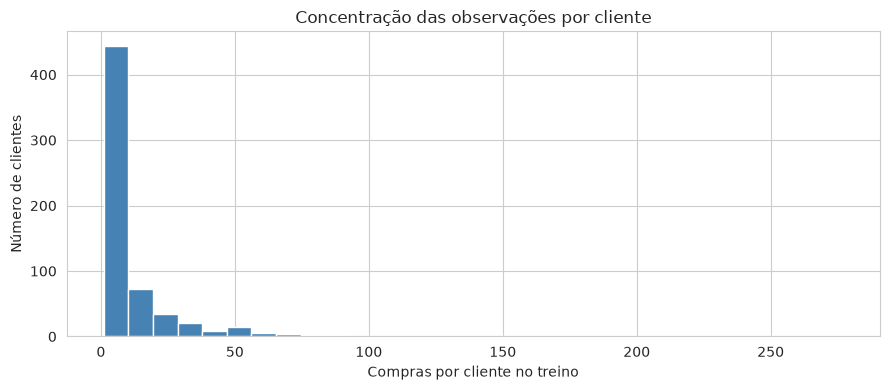

In [6]:
verificacao_chaves = pd.Series({
    "IDs de compra repetidos": train.index.duplicated().sum(),
    "Clientes distintos no treino": train["customer_id"].nunique(),
    "IDs repetidos na tabela de clientes": clients["customer_id"].duplicated().sum(),
    "Linhas integralmente repetidas, incluindo ID": train.reset_index().duplicated().sum(),
    "Repetições adicionais sem ID e random_noise": train.drop(columns="random_noise").duplicated().sum(),
    "Repetições adicionais do par cliente/data": train.duplicated(["customer_id", "purchase_date"]).sum(),
})
display(verificacao_chaves.to_frame("Resultado"))

compras_por_cliente = train.groupby("customer_id").size()
display(compras_por_cliente.describe().to_frame("Compras por cliente"))

compras_por_cliente.plot.hist(bins=30, figsize=(9, 4), color="steelblue")
plt.xlabel("Compras por cliente no treino")
plt.ylabel("Número de clientes")
plt.title("Concentração das observações por cliente")
plt.tight_layout()
plt.show()

In [8]:
def perfil_colunas(df):
    """Uma linha por variável; os nulos não contam como categoria distinta."""
    return pd.DataFrame({
        "Tipo armazenado": df.dtypes.astype(str),
        "Disponíveis": df.notna().sum(),
        "Nulos": df.isna().sum(),
        "Nulos (%)": df.isna().mean().mul(100),
        "Valores distintos": df.nunique(dropna=True),
    })

perfil_train = perfil_colunas(train)
perfil_clients = perfil_colunas(clients)
display(perfil_train.round(2))

numericas = train.select_dtypes(include="number").drop(columns=["customer_id", "repeat_purchase_90d"])
estatisticas_numericas = numericas.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).T
display(estatisticas_numericas.round(2))

,Tipo armazenado,Disponíveis,Nulos,Nulos (%),Valores distintos
Total a Pagar,float64,6469,65,0.99,6122
Total Bruto,float64,6469,65,0.99,6038
Total Liquido,float64,6469,65,0.99,6093
Total Imp_,float64,6469,65,0.99,5406
Total Portes,float64,6469,65,0.99,215
Total Desc_ Global,float64,6469,65,0.99,109
Total Desc_ Linha,float64,6469,65,0.99,3519
Custo,float64,6469,65,0.99,5736
N_ Detalhes,float64,6469,65,0.99,171
invoice_count_current_purchase,float64,6469,65,0.99,5


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
Total a Pagar,6469.0,925.56,1335.00,0.93,9.38,188.92,476.74,1087.67,3398.77,6543.97,2.229721e+04
Total Bruto,6469.0,886.15,1327.64,0.83,9.23,175.74,445.74,1036.70,3251.84,6717.62,2.157828e+04
Total Liquido,6469.0,773.34,1136.36,0.76,7.62,154.38,389.91,903.37,2838.59,5675.70,1.812781e+04
Total Imp_,6469.0,152.22,225.26,0.00,0.00,29.93,79.74,184.84,549.12,1026.79,4.169400e+03
Total Portes,6469.0,1.15,5.84,0.00,0.00,0.00,0.00,0.00,5.75,11.80,1.810600e+02
Total Desc_ Global,6469.0,0.35,5.12,0.00,0.00,0.00,0.00,0.00,0.00,7.85,2.184900e+02
Total Desc_ Linha,6469.0,112.47,289.99,0.00,0.00,0.00,13.13,92.28,540.39,1369.04,4.103440e+03
Custo,6469.0,328.17,519.51,0.00,0.00,49.05,152.54,396.06,1227.53,2382.10,7.427400e+03
N_ Detalhes,6469.0,21.52,27.71,1.00,1.00,4.00,11.00,29.00,75.00,128.00,4.230000e+02
invoice_count_current_purchase,6469.0,1.07,0.31,1.00,1.00,1.00,1.00,1.00,2.00,2.00,5.000000e+00


,Compras,Percentagem
repeat_purchase_90d,,
0,2880,44.08
1,3654,55.92


Valores em falta no alvo: 0


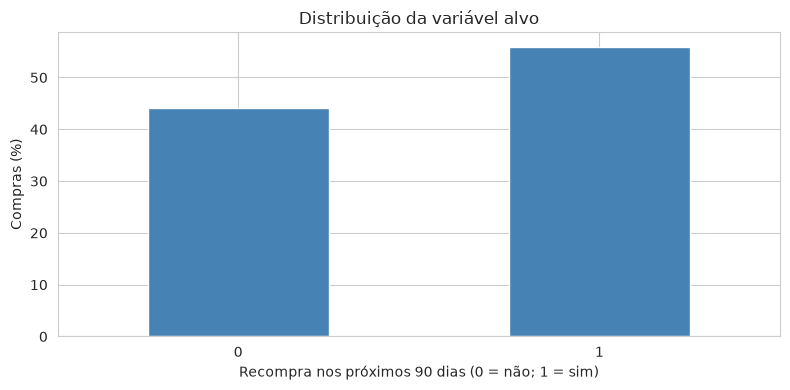

Taxa por compra: 55.9%
Média das taxas dando peso igual a cada cliente: 26.8%


In [9]:
resumo_alvo = pd.DataFrame({
    "Compras": train["repeat_purchase_90d"].value_counts(dropna=False),
    "Percentagem": train["repeat_purchase_90d"].value_counts(normalize=True, dropna=False).mul(100),
}).sort_index()
display(resumo_alvo.round(2))
print("Valores em falta no alvo:", train["repeat_purchase_90d"].isna().sum())

resumo_alvo["Percentagem"].plot.bar(figsize=(8, 4), color="steelblue")
plt.xlabel("Recompra nos próximos 90 dias (0 = não; 1 = sim)")
plt.ylabel("Compras (%)")
plt.title("Distribuição da variável alvo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

taxa_por_compra = train["repeat_purchase_90d"].mean()
taxa_peso_igual_cliente = train.groupby("customer_id")["repeat_purchase_90d"].mean().mean()
print(f"Taxa por compra: {taxa_por_compra:.1%}")
print(f"Média das taxas dando peso igual a cada cliente: {taxa_peso_igual_cliente:.1%}")

,Nulos,Nulos (%)
prior_std_gap_days,1478,22.62
prior_mean_gap_days,1308,20.02
prior_std_purchase_value,1113,17.03
prior_mean_purchase_value,862,13.19
days_since_previous_purchase,861,13.18
prior_max_purchase_value,668,10.22
prior_min_purchase_value,668,10.22
transport_method,261,3.99
warehouse,260,3.98
payment_type,260,3.98


Compras com pelo menos um nulo: 2,605 (39.9%)
Compras completas: 3,929


,Compras
Nulos na linha,
0,3929
1,1287
2,190
3,354
4,100
5,6
7,511
8,86
9,6


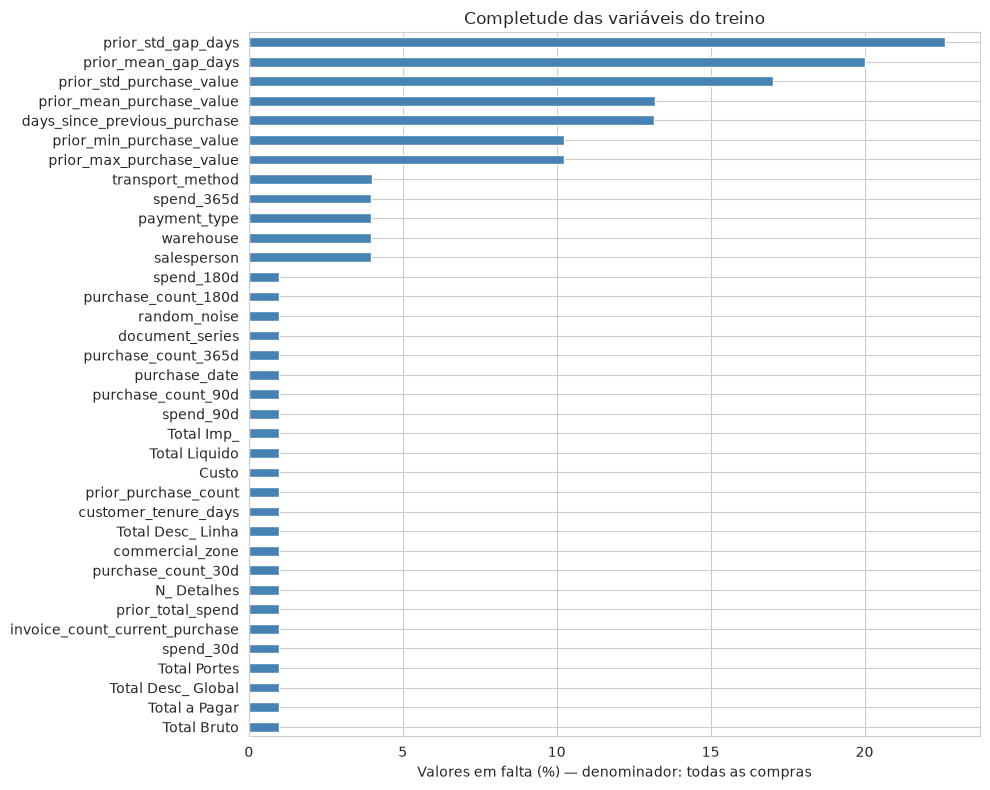

In [11]:
missing = perfil_train[["Nulos", "Nulos (%)"]].sort_values("Nulos (%)", ascending=False)
display(missing.loc[missing["Nulos"] > 0].round(2))

nulos_por_linha = train.isna().sum(axis=1)
print(f"Compras com pelo menos um nulo: {nulos_por_linha.gt(0).sum():,} ({nulos_por_linha.gt(0).mean():.1%})")
print(f"Compras completas: {nulos_por_linha.eq(0).sum():,}")
display(nulos_por_linha.value_counts().sort_index().rename_axis("Nulos na linha").to_frame("Compras"))

missing.loc[missing["Nulos"] > 0, "Nulos (%)"].sort_values().plot.barh(
    figsize=(10, 8), color="steelblue"
)
plt.xlabel("Valores em falta (%) — denominador: todas as compras")
plt.title("Completude das variáveis do treino")
plt.tight_layout()
plt.show()

In [13]:
linhas_muito_incompletas = nulos_por_linha.eq(36)
print("Compras com 36 campos em falta:", linhas_muito_incompletas.sum())
print("Campos preenchidos nessas linhas (além do índice ID):")
disponibilidade = train.loc[linhas_muito_incompletas].notna().sum()
display(disponibilidade.loc[disponibilidade > 0].to_frame("Disponíveis"))

resumo_incompletude = train.groupby(linhas_muito_incompletas)["repeat_purchase_90d"].agg(
    compras="size", taxa_recompra="mean"
)
resumo_incompletude.index.name = "Tem 36 campos em falta"
display(resumo_incompletude)

Compras com 36 campos em falta: 65
Campos preenchidos nessas linhas (além do índice ID):


,Disponíveis
repeat_purchase_90d,65
customer_id,65


,compras,taxa_recompra
Tem 36 campos em falta,,
False,6469,0.559746
True,65,0.507692


,Compras
Histórico,
Com histórico,5866
Sem histórico,603
Desconhecido,65


,days_since_previous_purchase,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days
Histórico,,,,,,,
Com histórico,3.29,3.31,7.59,0.0,0.0,10.91,13.81
Desconhecido,100.00,100.00,100.00,100.0,100.0,100.00,100.00
Sem histórico,100.00,100.00,100.00,100.0,100.0,100.00,100.00


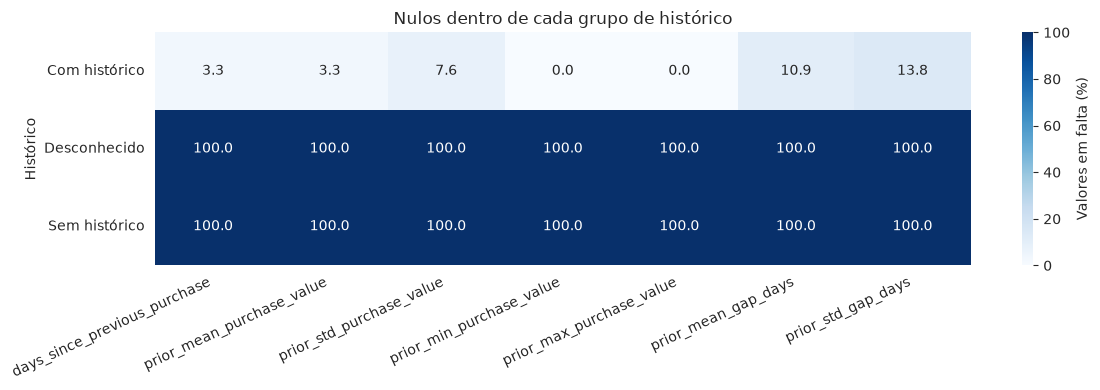

In [14]:
colunas_historico = [
    "days_since_previous_purchase", "prior_mean_purchase_value",
    "prior_std_purchase_value", "prior_min_purchase_value",
    "prior_max_purchase_value", "prior_mean_gap_days", "prior_std_gap_days",
]
grupo_historico = pd.Series("Contagem inválida", index=train.index, name="Histórico")
grupo_historico.loc[train["prior_purchase_count"].gt(0)] = "Com histórico"
grupo_historico.loc[train["prior_purchase_count"].eq(0)] = "Sem histórico"
grupo_historico.loc[train["prior_purchase_count"].isna()] = "Desconhecido"

nulos_historico = train[colunas_historico].isna().groupby(grupo_historico).mean().mul(100)
display(grupo_historico.value_counts().to_frame("Compras"))
display(nulos_historico.round(2))

plt.figure(figsize=(12, 4))
sns.heatmap(nulos_historico, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "Valores em falta (%)"})
plt.title("Nulos dentro de cada grupo de histórico")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()